## Lab07  Phân lớp dữ liệu bệnh tiểu đường

Import thư viện

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

Tải dữ liệu

In [10]:

file_path = 'pima.csv' 

column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']

pima = pd.read_csv(file_path, names=column_names)

X = pima.drop('Outcome', axis=1)
y = pima['Outcome']

Tiền xử lý dữ liệu

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.copy()
X_test = X_test.copy()

cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_fix:
    X_train[col] = X_train[col].replace(0, np.nan)
    X_test[col] = X_test[col].replace(0, np.nan)
    train_median = X_train[col].median()
    
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Huấn luyện mô hình

In [12]:

models = [
    ('Naive Bayes', GaussianNB()), 
    ('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)), 
    ('SVM (RBF Kernel)', SVC(kernel='rbf', probability=True, random_state=42)) 
]

model_names = []
accuracies = []

for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_names.append(name)
    accuracies.append(acc)

Phân lớp mô hình bằng 3 thuật toán : Naive Bayes, K-Means (k=2), SVM (RBF Kernel)

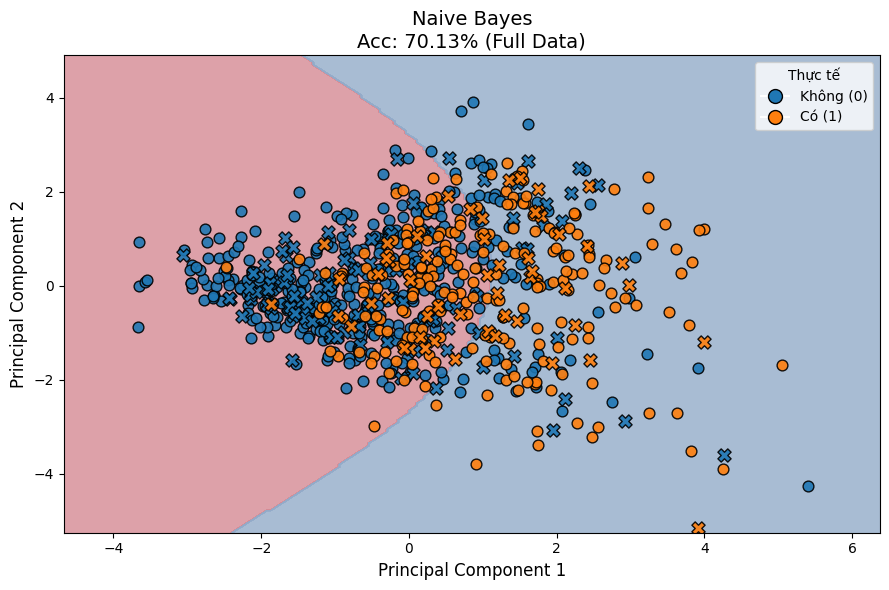

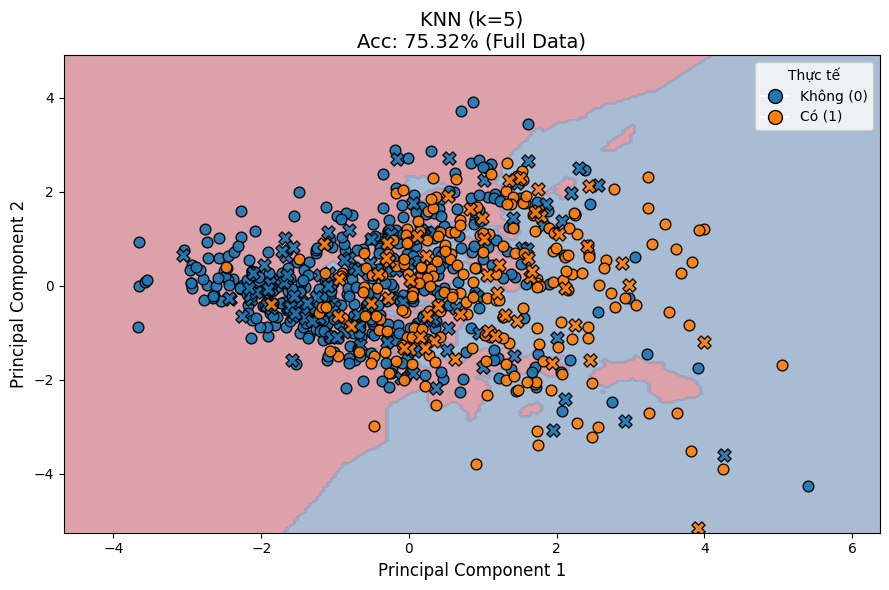

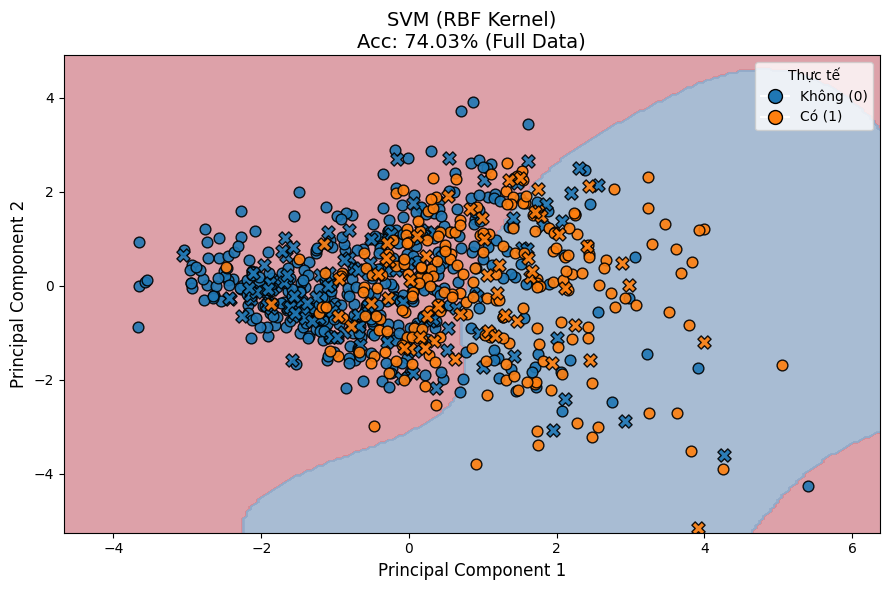

In [13]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
cmap_background = ListedColormap(['#d58a94', '#93abc9']) 

for i, (name, model) in enumerate(models):
    plt.figure(figsize=(9, 6)) 
    model_2d = model
    model_2d.fit(X_train_pca, y_train)
    
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.8)
    
    for label, color in zip([0, 1], ['#1f77b4', '#ff7f0e']):
        idx_train = (y_train == label)
        plt.scatter(X_train_pca[idx_train, 0], X_train_pca[idx_train, 1],
                    c=color, edgecolor='k', s=60, alpha=0.9)
        
        idx_test = (y_test == label)
        plt.scatter(X_test_pca[idx_test, 0], X_test_pca[idx_test, 1],
                    c=color, edgecolor='k', marker='X', s=90, alpha=0.9)
    
    plt.title(f"{name}\nAcc: {accuracies[i]*100:.2f}% (Full Data)", size=14)
    plt.xlabel("Principal Component 1", size=12)
    plt.ylabel("Principal Component 2", size=12)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Không (0)', markerfacecolor='#1f77b4', markersize=10, markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', label='Có (1)', markerfacecolor='#ff7f0e', markersize=10, markeredgecolor='k')
    ]
    plt.legend(handles=legend_elements, title="Thực tế", loc="upper right")
    
    plt.tight_layout()
    plt.show()


So sánh sự phân lớp của 3 mô hình

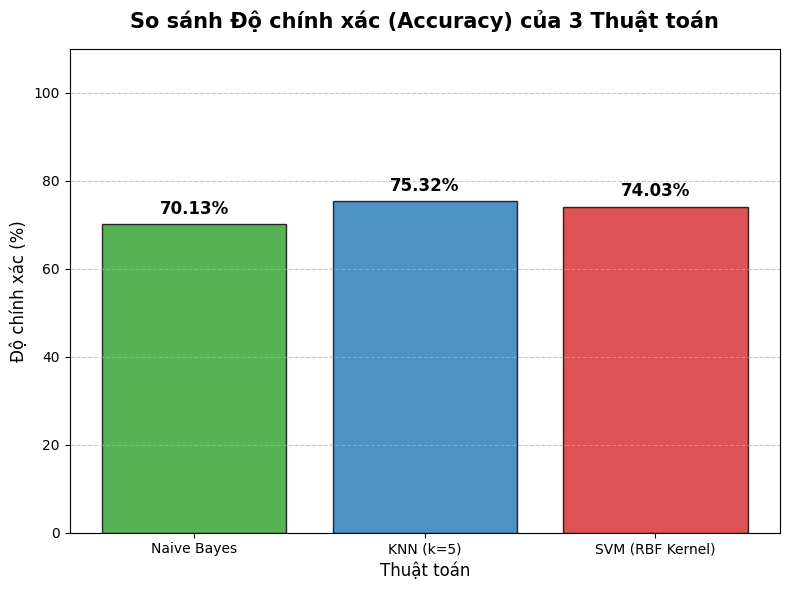

In [14]:
plt.figure(figsize=(8, 6))

accuracies_pct = [acc * 100 for acc in accuracies]

colors = ['#2ca02c', '#1f77b4', '#d62728'] 
bars = plt.bar(model_names, accuracies_pct, color=colors, edgecolor='black', alpha=0.8)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, 
             f'{yval:.2f}%', ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

plt.title('So sánh Độ chính xác (Accuracy) của 3 Thuật toán', size=15, fontweight='bold', pad=15)
plt.ylabel('Độ chính xác (%)', size=12)
plt.xlabel('Thuật toán', size=12)
plt.ylim(0, 110) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Tìm tham số tối ưu

In [15]:
print("\n" + "="*42)
print("PHẦN: TÌM THAM SỐ TỐI ƯU (HYPERPARAMETER TUNING)")
print("="*42)

param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 'auto', 0.01, 0.001]
    },
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    }
]

grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_

print(f"\n✅ Kết quả tìm kiếm:")
print(f"- Tham số tối ưu: {grid_search.best_params_}")
print(f"- Độ chính xác tốt nhất (Cross-Validation): {grid_search.best_score_ * 100:.2f}%")

y_pred_tuned = best_svm.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred_tuned)
print(f"- Độ chính xác trên tập Test (Thực tế): {acc_test * 100:.2f}%")

gap = (grid_search.best_score_ - acc_test) * 100
print(f"- Độ lệch Train-Test: {gap:.2f}%")


PHẦN: TÌM THAM SỐ TỐI ƯU (HYPERPARAMETER TUNING)
Fitting 5 folds for each of 19 candidates, totalling 95 fits

✅ Kết quả tìm kiếm:
- Tham số tối ưu: {'C': 50, 'gamma': 0.001, 'kernel': 'rbf'}
- Độ chính xác tốt nhất (Cross-Validation): 77.69%
- Độ chính xác trên tập Test (Thực tế): 70.13%
- Độ lệch Train-Test: 7.56%
